
**EXPERIMENT ONE**

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Communication overhead for round 1: 1.4054 MB
Global model accuracy after round 1: 0.0556
Round 2/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Communication overhead for round 2: 1.4054 MB
Global model accuracy after round 2: 0.1564
Round 3/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Communic

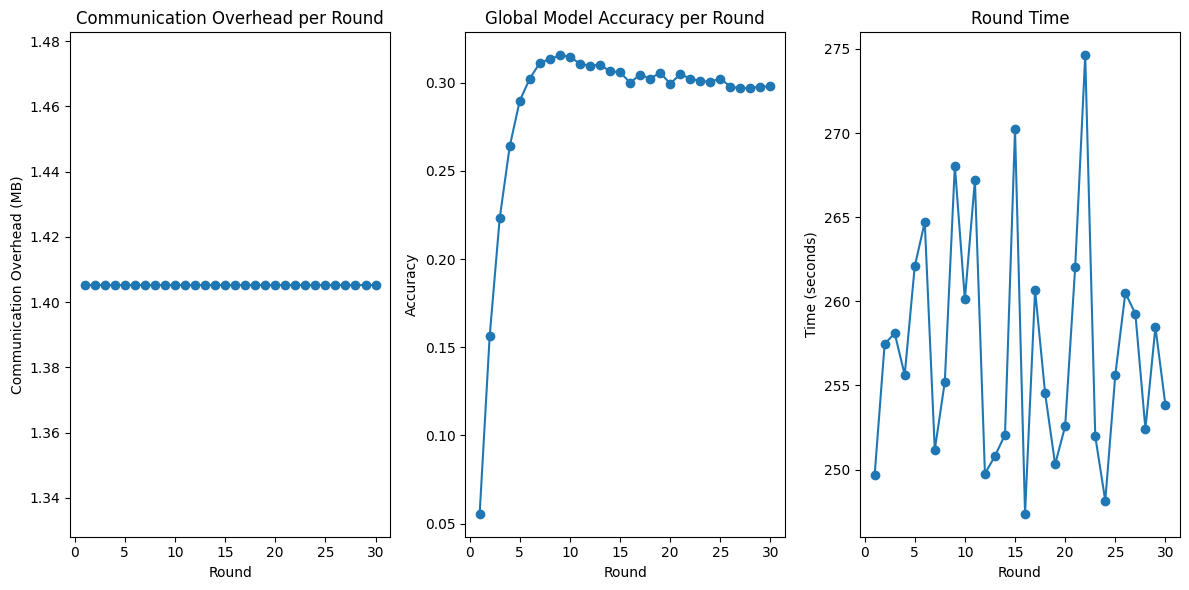

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Loading and preprocessing the CIFAR-100 dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

    # Normalizing the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Converting to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(100, activation='softmax')  # 100 classes for CIFAR-100
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=10):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 10
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (32, 32, 3)  # Inputing shape for the CIFAR-100 dataset
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT TWO**

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Communication overhead for round 1: 1.4054 MB
Global model accuracy after round 1: 0.0352
Round 2/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Tra

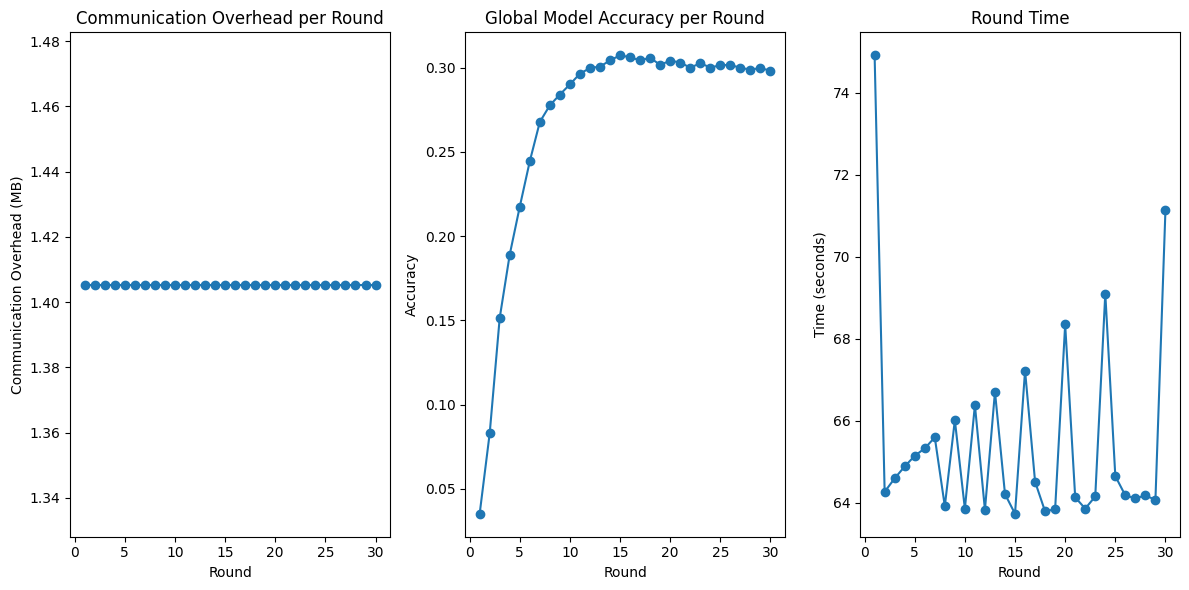

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the CIFAR-100 dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(100, activation='softmax')  # 100 classes for CIFAR-100
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=10):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 20
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (32, 32, 3)
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT THREE**

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Communication overhead for round 1: 1.4054 MB
Global model accuracy after round 1: 0.0288
Round 2/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Trainin

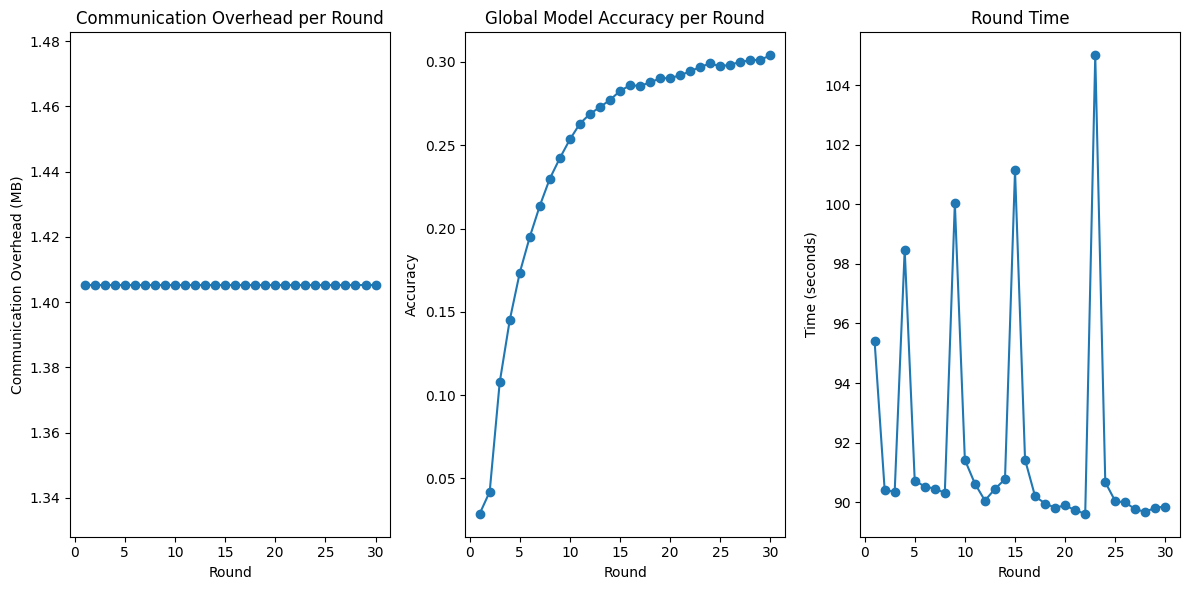

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the CIFAR-100 dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(100, activation='softmax')  # 100 classes for CIFAR-100
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=10):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 30
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (32, 32, 3)
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT FOUR**

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on clie

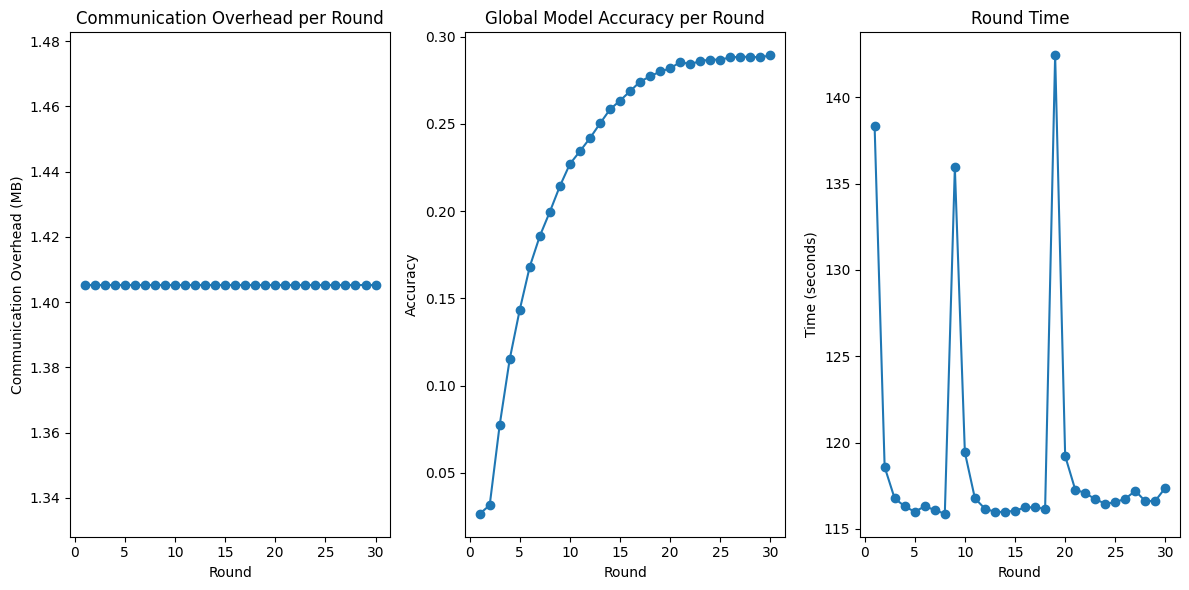

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the CIFAR-100 dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(100, activation='softmax')  # 100 classes for CIFAR-100
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=10):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 40
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  #  accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (32, 32, 3)
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT FIVE**

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Trainin

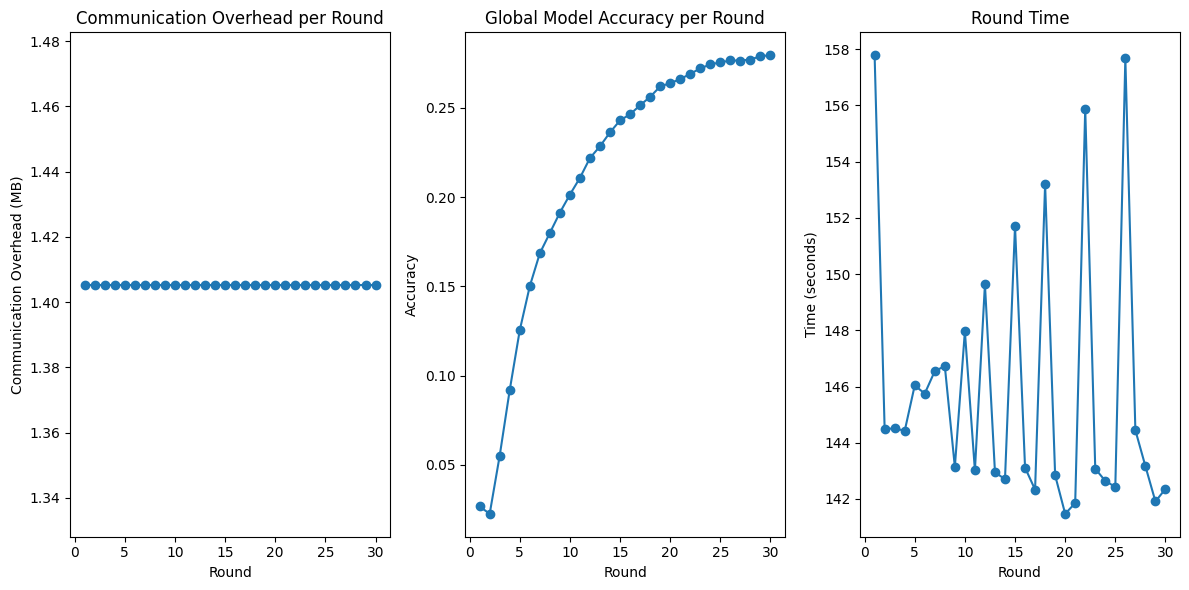

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the CIFAR-100 dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(100, activation='softmax')  # 100 classes for CIFAR-100
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=10):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 50
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (32, 32, 3)
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT SIX**

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 37s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Traini

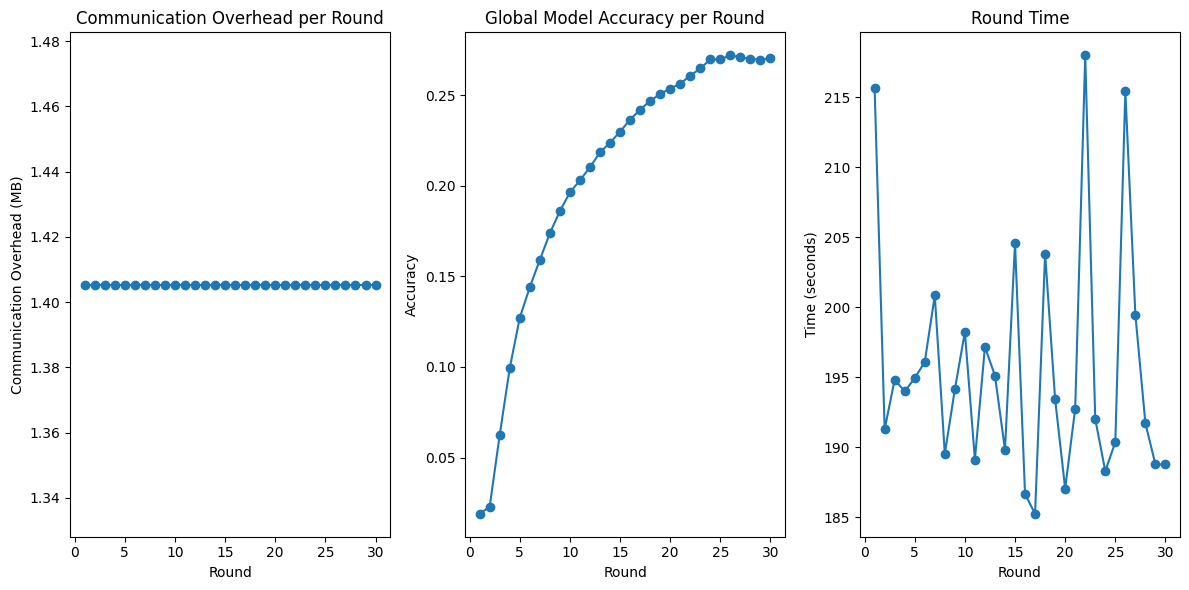

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the CIFAR-100 dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(100, activation='softmax')  # 100 classes for CIFAR-100
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=60):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 60
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (32, 32, 3)
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.6 MB/s eta 0:00:00


**EXPERIMENT SEVEN**

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Trainin

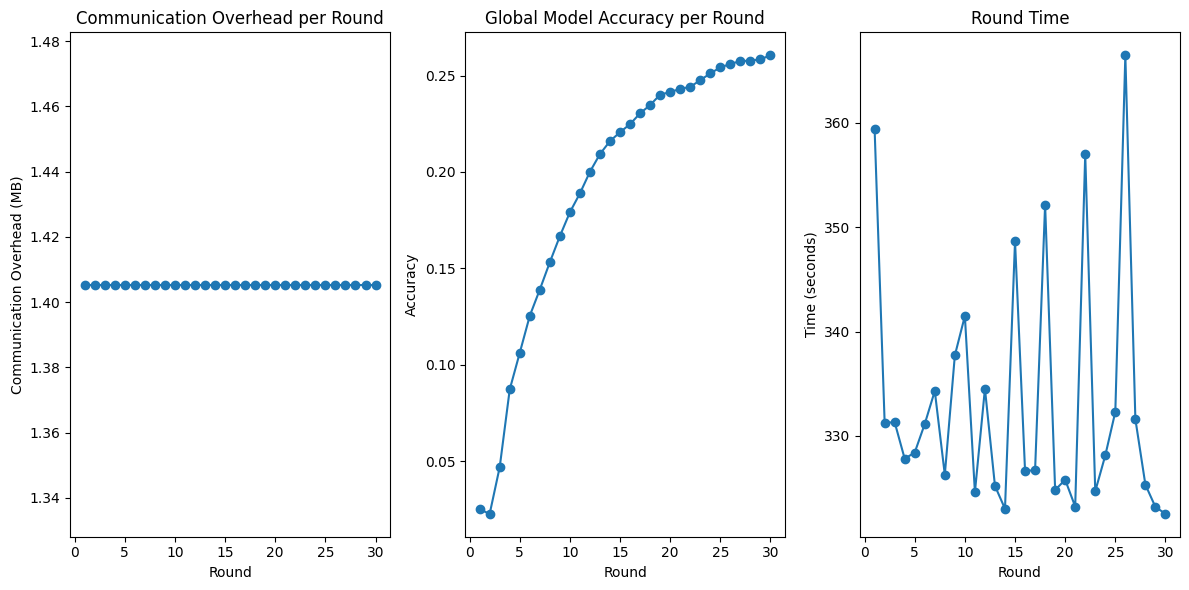

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the CIFAR-100 dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(100, activation='softmax')  # 100 classes for CIFAR-100
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=70):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 70
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  #  accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (32, 32, 3)
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT EIGHT**

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Trainin

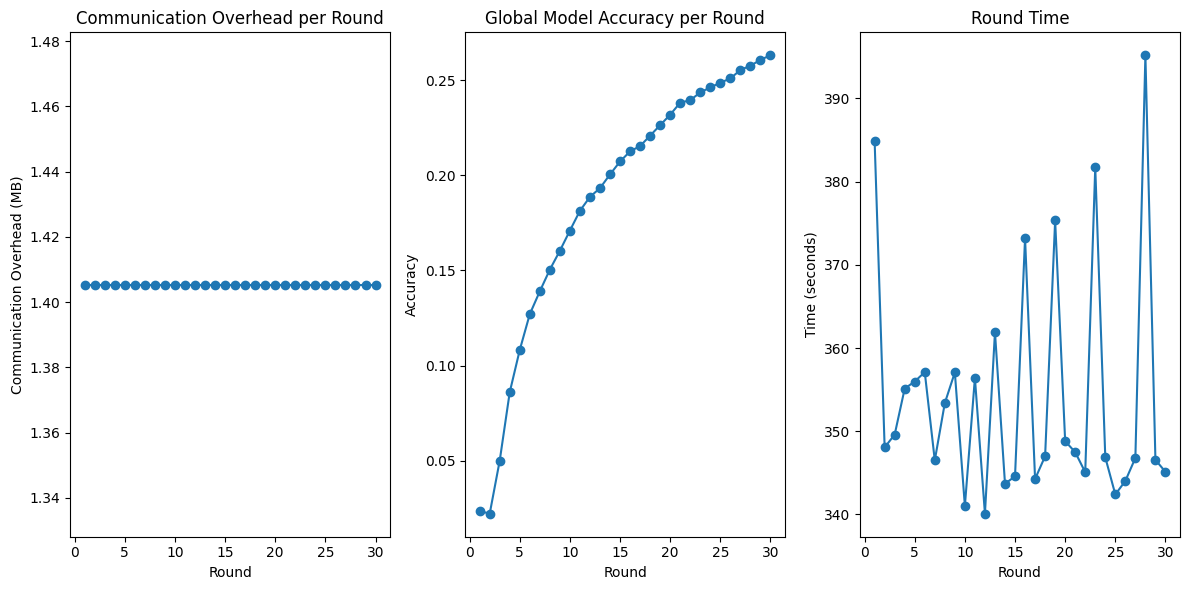

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the CIFAR-100 dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(100, activation='softmax')  # 100 classes for CIFAR-100
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=80):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 80
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (32, 32, 3)
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT NINE**

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Trainin

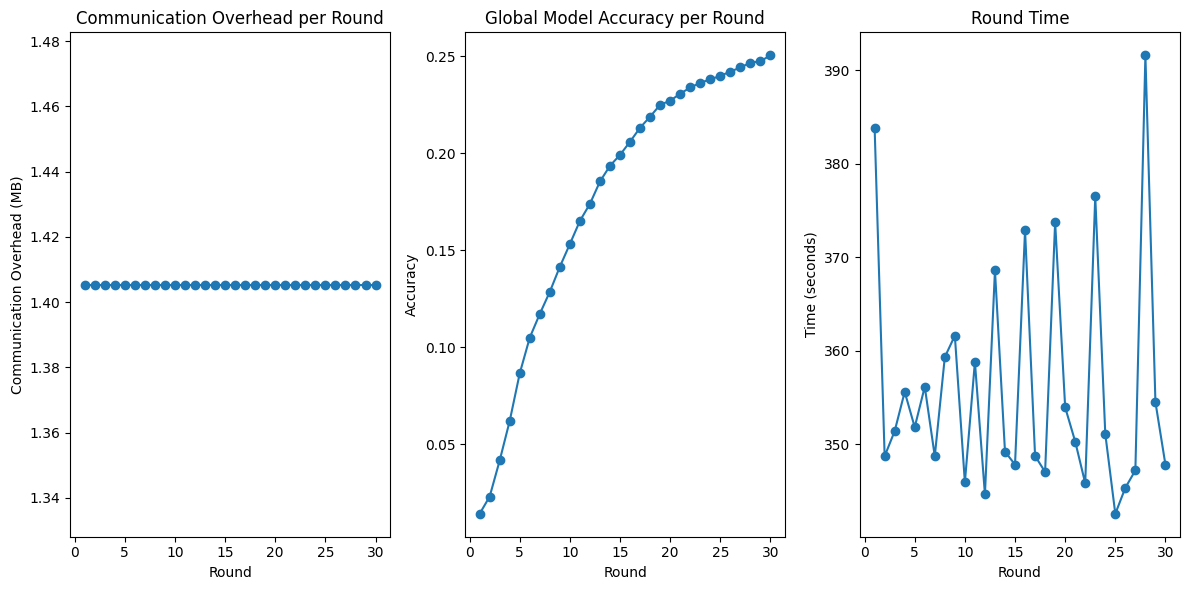

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the CIFAR-100 dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(100, activation='softmax')  # 100 classes for CIFAR-100
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=80):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 80
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  #  accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (32, 32, 3)
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT TEN**

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on clie

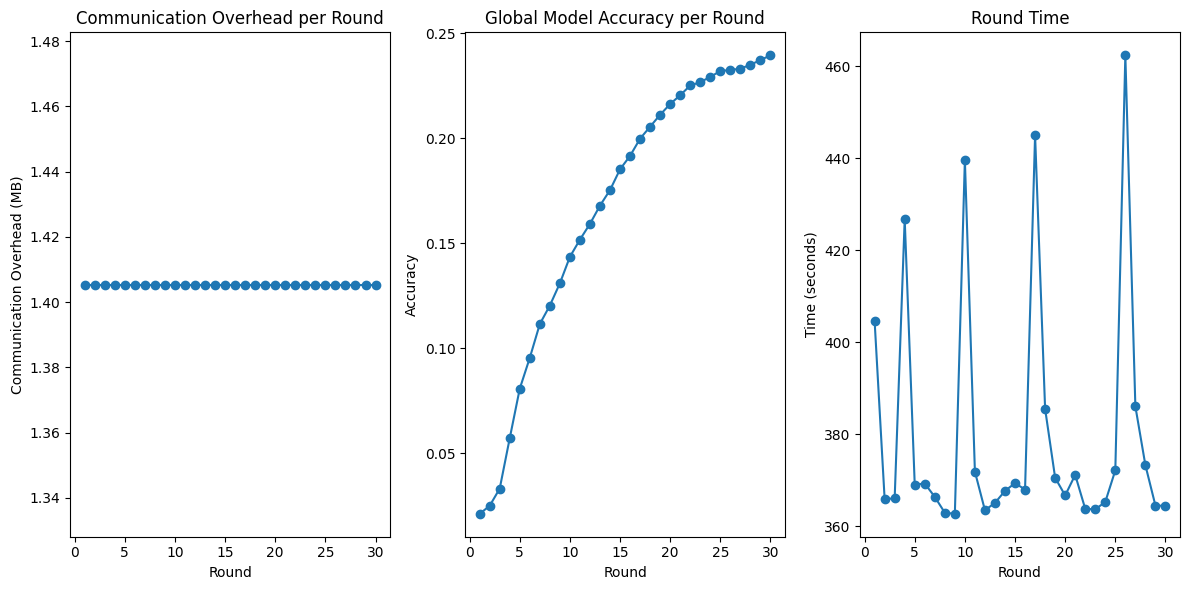

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the CIFAR-100 dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(100, activation='softmax')  # 100 classes for CIFAR-100
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=90):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 90
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (32, 32, 3)
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**CENTRALIZED EXPERIMENT**

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on clie

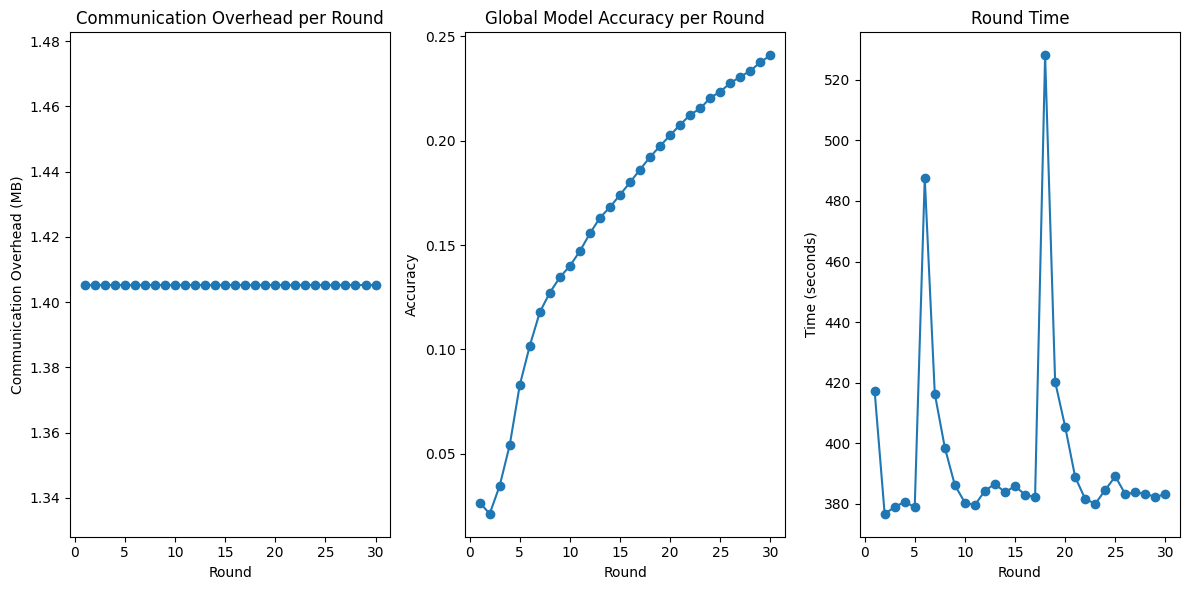

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the CIFAR-100 dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(100, activation='softmax')  # 100 classes for CIFAR-100
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=100):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 100
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  #  accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (32, 32, 3)
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 605.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.3 MB/s eta 0:00:00


169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)
Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.0589 - loss: 4.2044 - val_accuracy: 0.1729 - val_loss: 3.4561
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.1901 - loss: 3.3786 - val_accuracy: 0.2436 - val_loss: 3.0942
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.2603 - loss: 3.0100 - val_accuracy: 0.2852 - val_loss: 2.8949
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3051 - loss: 2.7753 - val_accuracy: 0.3017 - val_loss: 2.7943
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3373 - loss: 2.6054 - val_accuracy: 0.3157 - val_loss: 2.7291
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3635 - loss: 2.4780 - val_accuracy: 0.3253 - val_loss: 2.7103
Epoch 7/30
1563

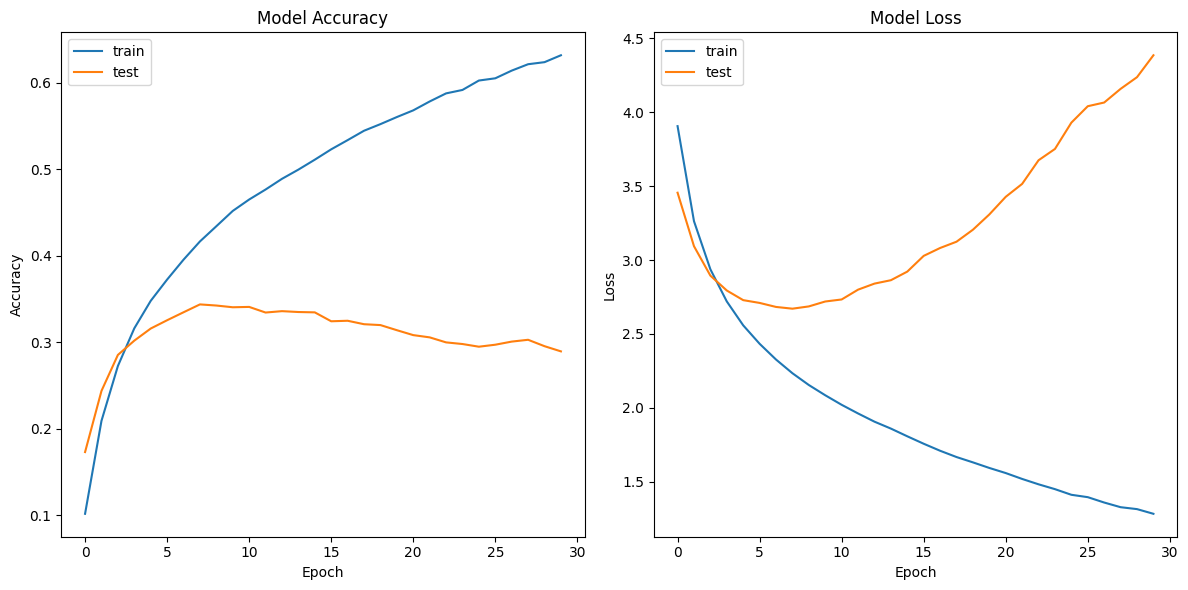

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the CIFAR-100 dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(100, activation='softmax')  # 100 classes for CIFAR-100
    ])
    return model

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create and compile the model
input_shape = (32, 32, 3)
model = create_cnn_model(input_shape)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
start_time = time.time()
history = model.fit(train_ds, epochs=30, batch_size=32, validation_data=test_ds, verbose=1)
training_time = time.time() - start_time

# Evaluate the model
final_loss, final_accuracy = model.evaluate(test_ds, verbose=0)
print(f"Final model accuracy: {final_accuracy:.4f}")
print(f"Training time: {training_time:.2f} seconds")

# Visualization
plt.figure(figsize=(12, 6))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()